# Chapter 6: CycleGAN: Converting Blond Hair to Black Hair

This chapter covers
* The idea behind CycleGAN and cycle consistency loss 
* Building a CycleGAN model to translate images from one domain to another 
* Training a CycleGAN by using any dataset with two domains of images
* Training a CycleGAN to convert black hair to blond hair and vice versa

The GAN models we have discussed in the last three chapters are all trying to produce images that are indistinguishable from those in the training set. 

You may be wondering: Can we translate images from one domain to another, such as transforming horses into zebras, converting black hair to blond hair or blond hair to black, adding or removing eyeglasses in images, turning photographs into paintings, or converting winter scenes to summer scenes? 

It turns out you can, and you’ll acquire such skills in this chapter through CycleGAN!

CycleGAN was introduced in a paper by Jun-Yan Zhu et al in 2017. The key innovation of CycleGAN is its ability to learn to translate between domains without paired examples. CycleGAN has a variety of interesting and useful applications, such as simulating the aging or rejuvenation process on faces to assist digital identity verification or visualizing clothing in different colors or patterns without physically creating each variant to streamline the design process. 

CycleGAN uses a cycle consistency loss function to ensure the original image can be reconstructed from the transformed image, encouraging the preservation of key features. The idea behind cycle consistency loss is truly ingenious and deserves some highlight here. The CycleGAN in this chapter has two generators: let's call them the black hair generator and the blond hair generator, respectively. The black hair generator takes in an image with blond hair (instead of a random noise vector as you have seen before) and converts it to one with black hair, while the blond hair generator takes in an image with black hair and converts it to one with blond hair.

To train the model, we'll give a real image with black hair to the blond hair generator to produce a fake image with blond hair. We'll then give the fake blond hair image to the black hair generator to convert it back to an image with black hair. If both generators work well, there is little difference between the original image with black hair and the fake one after a roundtrip conversion. To train the CycleGAN, we adjust the model parameters to minimize the sum of adversarial losses and cycle consistency losses. As in Chapters 3 and 4, adversarial losses are used to quantify how well the generator can fool the discriminator and how well the discriminator can differentiate between real and fake samples. Cycle consistency loss, a unique concept in CycleGANs, measures the difference between the original image and the fake image after a roundtrip conversion. The inclusion of the cycle consistency loss in the total loss function is the key innovation in CycleGANs.

You’ll use two new Python libraries in this chapter: pandas and albumentations. To install these libraries, execute the following line of code in a new cell in your Jupyter Notebook application on your computer:

In [1]:
# installation
!pip install pandas albumentations

# 1. CycleGAN and Cycle Consistency Loss

# 2. The celebrity faces dataset

## 2.1. Download the Celebrity Faces Dataset
You can download the celebrity faces dataset is from Kaggle. Log into Kaggle and go to the link https://www.kaggle.com/datasets/jessicali9530/celeba-dataset to download dataset. 

In [2]:
import pandas as pd
import os, shutil

df=pd.read_csv("files/list_attr_celeba.csv")    #A
os.makedirs("files/black", exist_ok=True)  
os.makedirs("files/blond", exist_ok=True)    #B      
folder="files/img_align_celeba/img_align_celeba"
for i in range(len(df)):
    dfi=df.iloc[i]
    if dfi['Black_Hair']==1:    #C
        try:
            oldpath=f"{folder}/{dfi['image_id']}"
            newpath=f"files/black/{dfi['image_id']}"
            shutil.move(oldpath, newpath)
        except:
            pass
    elif dfi['Blond_Hair']==1:    #D
        try:
            oldpath=f"{folder}/{dfi['image_id']}"
            newpath=f"files/blond/{dfi['image_id']}"
            shutil.move(oldpath, newpath)
        except:
            pass

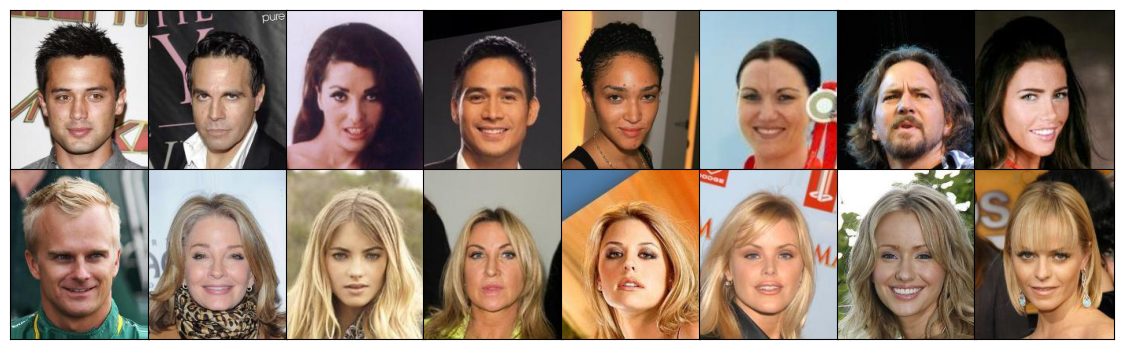

In [3]:
trainA=r"files/black/"
trainB=r"files/blond/"

import random
import matplotlib.pyplot as plt
from PIL import Image

imgs=os.listdir(trainA)
random.seed(42)
samples=random.sample(imgs,8)
imgs1=os.listdir(trainB)
random.seed(42)
samples1=random.sample(imgs1,8)
fs=[trainA,trainB]
ps=[imgs,imgs1]
fig=plt.figure(dpi=100, figsize=(1.78*8,2.18*2))
for i in range(16):
    ax = plt.subplot(2, 8, i + 1)
    folder=i//8
    p=i%8
    img=Image.open(fr"{fs[folder]}{ps[folder][p]}")
    plt.imshow(img)
    plt.xticks([])
    plt.yticks([])
plt.subplots_adjust(wspace=-0.01,hspace=-0.1)
plt.show() 

## 2.2	Process the black and blond hair image data

In [4]:
from utils.ch06util import LoadData
from torch.utils.data import DataLoader
from tqdm import tqdm
import albumentations 
from albumentations.pytorch import ToTensorV2

transforms = albumentations.Compose(
    [albumentations.Resize(width=256, height=256),    #A
        albumentations.HorizontalFlip(p=0.5),
        albumentations.Normalize(mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5],max_pixel_value=255),    #B
        ToTensorV2()],
    additional_targets={"image0": "image"}) 
dataset = LoadData(root_A=["files/black/"],
    root_B=["files/blond/"],
    transform=transforms)    #C
loader=DataLoader(dataset,batch_size=1,
    shuffle=True, pin_memory=True)    #D

# 3. Build a CycleGAN model
## 3.1	Create two discriminators

In [5]:
from utils.ch06util import Discriminator, weights_init    #A
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
disc_A = Discriminator().to(device)
disc_B = Discriminator().to(device)    #B
weights_init(disc_A)
weights_init(disc_B)    #C

## 3.2	Create two generators

In [6]:
from utils.ch06util import Generator

gen_A = Generator(img_channels=3, num_residuals=9).to(device)
gen_B = Generator(img_channels=3, num_residuals=9).to(device)
weights_init(gen_A)
weights_init(gen_B)

In [7]:
import torch.nn as nn

l1 = nn.L1Loss()
mse = nn.MSELoss()
g_scaler = torch.cuda.amp.GradScaler()
d_scaler = torch.cuda.amp.GradScaler()

In [8]:
lr = 0.00001
opt_disc = torch.optim.Adam(list(disc_A.parameters()) + 
  list(disc_B.parameters()),lr=lr,betas=(0.5, 0.999))
opt_gen = torch.optim.Adam(list(gen_A.parameters()) + 
  list(gen_B.parameters()),lr=lr,betas=(0.5, 0.999))

# 4. CycleGAN to translate between black and blond hair
## 4.1	Train a CycleGAN to translate between black and blond hair

In [9]:
def test(i,A,B,fake_A,fake_B):
    save_image(A*0.5+0.5,f"files/A{i}.png")
    save_image(B*0.5+0.5,f"files/B{i}.png")    #A
    save_image(fake_A*0.5+0.5,f"files/fakeA{i}.png")
    save_image(fake_B*0.5+0.5,f"files/fakeB{i}.png")    #B

In [10]:
from utils.ch06util import train_epoch

for epoch in range(1):
    train_epoch(disc_A, disc_B, gen_A, gen_B, loader, opt_disc,
    opt_gen, l1, mse, d_scaler, g_scaler, device)    #A
torch.save(gen_A.state_dict(), "files/gen_black.pth")
torch.save(gen_B.state_dict(), "files/gen_blond.pth")    #B

Download the pretrained model from my website https://gattonweb.uky.edu/faculty/lium/ml/hair.zip 

In [11]:
# answer to exercise 6.1
dataset = LoadData(root_A=["files/blond/"],
    root_B=["files/black/"],
    transform=transforms)    

## 4.2. Roundtrip conversions of black hair images and blond hair images

In [12]:
from torchvision.utils import save_image

gen_A.load_state_dict(torch.load("files/gen_black.pth"))
gen_B.load_state_dict(torch.load("files/gen_blond.pth"))
i=1
for black,blond in loader:
    fake_blond=gen_B(black.to(device))
    save_image(black*0.5+0.5,f"files/black{i}.png")
    save_image(fake_blond*0.5+0.5,f"files/fakeblond{i}.png")   
    fake2black=gen_A(fake_blond)
    save_image(fake2black*0.5+0.5,f"files/fake2black{i}.png")    
    fake_black=gen_A(blond.to(device))
    save_image(blond*0.5+0.5,f"files/blond{i}.png")
    save_image(fake_black*0.5+0.5,f"files/fakeblack{i}.png")
    fake2blond=gen_B(fake_black)
    save_image(fake2blond*0.5+0.5,f"files/fake2blond{i}.png")  
    i=i+1
    if i>10:
        break

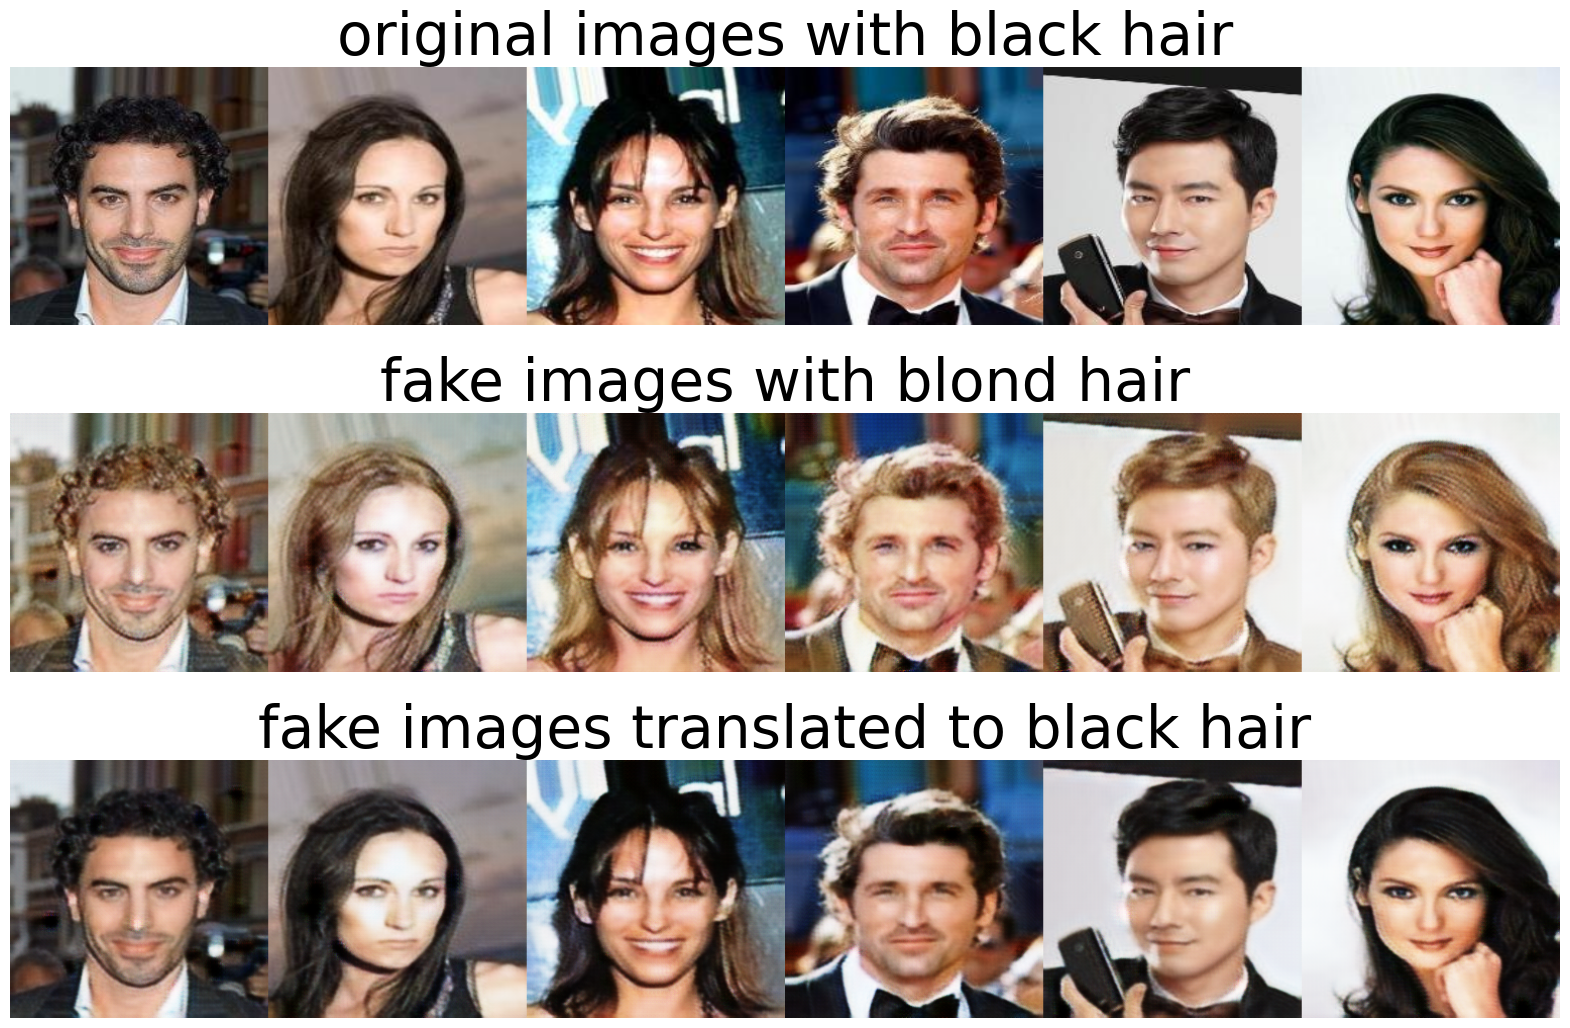




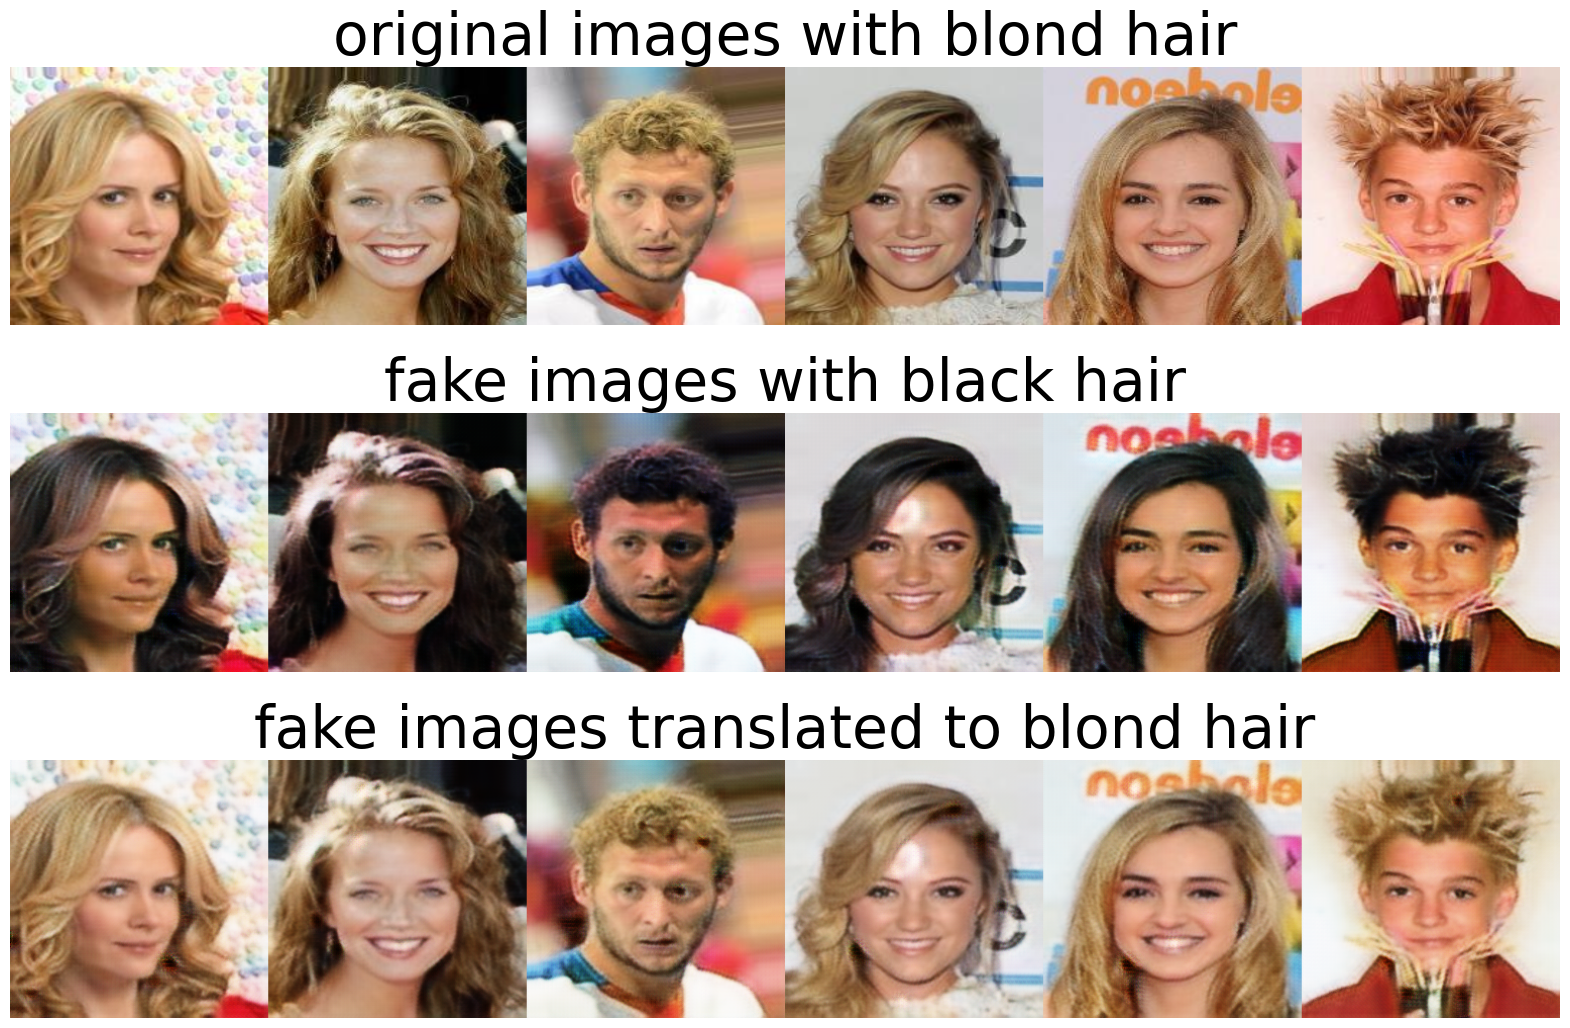

In [13]:
# solution to exercise 6.2

disc_A = Discriminator().to(device)
disc_B = Discriminator().to(device)
gen_A = Generator(img_channels=3, num_residuals=9).to(device)
gen_B = Generator(img_channels=3, num_residuals=9).to(device)
weights_init(gen_A)
weights_init(disc_A)
weights_init(gen_B)
weights_init(disc_B)
opt_disc = torch.optim.Adam(list(disc_A.parameters()) + 
  list(disc_B.parameters()),lr=lr,betas=(0.5, 0.999))
opt_gen = torch.optim.Adam(list(gen_A.parameters()) + 
  list(gen_B.parameters()),lr=lr,betas=(0.5, 0.999))

# make sure all images with glasses are placed in 'files/glasses/G/'
# all images without glasses are placed in 'files/glasses/NoG/'
# Manually move images to the correct folder if they are mislabelled
dataset = LoadData(root_A=['files/glasses/G/'],
    root_B=['files/glasses/NoG/'],
    transform=transforms)
loader=DataLoader(dataset,batch_size=1,
    shuffle=True, pin_memory=True)
for epoch in range(1):
    train_epoch(disc_A, disc_B, gen_A, gen_B, loader, opt_disc,
    opt_gen, l1, mse, d_scaler, g_scaler, device)
torch.save(gen_A.state_dict(), "files/add_glasses.pth")
torch.save(gen_B.state_dict(), "files/remove_glasses.pth")

How the trained model removes glasses: the left image in each pair are the original image with glasses; the image on the right is the one after the trained model removed the glasses from the image
<img src="https://gattonweb.uky.edu/faculty/lium/ml/removeglasses.jpg" />   

How the trained model adds glasses: the left image in each pair are the original image without glasses; the image on the right is the one after the trained model added glasses to the image
<img src="https://gattonweb.uky.edu/faculty/lium/ml/addglasses.jpg" />   